# Dynamic Phase reading
Imports a specific file produced during a dynamic phase

Dugr, 2026-09-21

In [ ]:
import json
import pandas as pd
from matplotlib import pyplot as plt


In [ ]:
base_dir = "C:/Users/gregor.dudle/OneDrive - OST/aFE/2026_Kibble/"
results_dir = base_dir + "Results/"
df = pd.DataFrame()

data_file = results_dir + "Simulation_20260922065029Z_res.json"
with open(data_file) as f:
    data_meta = json.load(f)
    f.close()

display(data_meta["metadata"])
data = pd.DataFrame(data_meta["data"])
data["B_l"] = data["coil.p.v"]/data["der(coil.pos_a.s)"]
display(data["coil.p.v"])


{'id': '20260922064846Z',
 'date': '2026-09-22 08:49:02',
 'user': 'gregor.dudle',
 'KibbleBalanceModel': 'DynamicPhaseV03',
 'CoilModel': 'BIPM_coil_2V3',
 'MagneticField': 'BIPM_magnetic_field_01',
 'Motion': {'Driver': 'triangular_position',
  'Amplitude': 0.01,
  'Period': 11,
  'Offset': 0.0},
 'Simulation': {'startTime': 0.0,
  'stopTime': 100.0,
  'numberOfIntervals': 5000,
  'tolerance': 1e-06,
  'method': 'dassl',
  'fileNamePrefix': 'DynamicPhaseV03',
  'options': '',
  'outputFormat': 'csv',
  'variableFilter': '.*',
  'cflags': '',
  'simflags': '-override=peri=11,ampli=0.01'}}

0      -1.766159
1      -1.766170
2      -1.766181
3      -1.766186
4      -1.766183
          ...   
5024   -1.766156
5025   -1.766161
5026   -1.766165
5027   -1.766170
5028   -1.766170
Name: coil.p.v, Length: 5029, dtype: float64

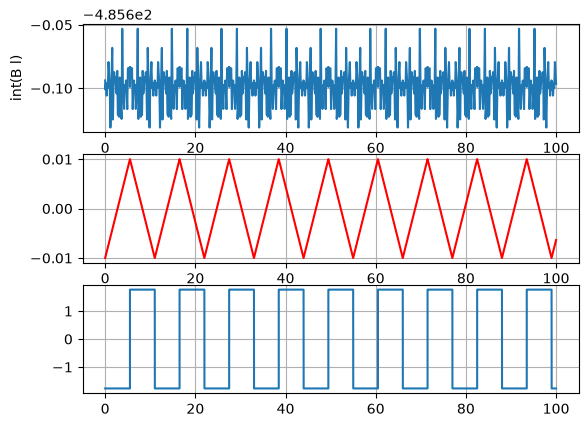

In [93]:
fig,ax = plt.subplots(3)
ax[0].plot(data["time"],data["B_l"])
ax[0].set_ylabel("int(B l)")
ax[0].grid()
ax[1].plot(data["time"],data["coil.pos_a.s"],"r")
ax[1].set_xlabel("Time / s")
ax[1].grid()
ax[2].plot(data["time"],data["coil.p.v"])
ax[2].grid()

In [ ]:
limite = 0.0025
time_list = data["time"][abs(data["coil.pos_a.s"])<limite]
B_l_list = data["B_l"][abs(data["coil.pos_a.s"])<limite]
pos_list = data["coil.pos_a.s"][abs(data["coil.pos_a.s"])<limite]

fig,ax = plt.subplots(2)
ax[0].scatter(time_list,B_l_list)
ax[1].scatter(pos_list,B_l_list)